In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
import joblib
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

In [100]:
# Load Dataset
df = pd.read_csv('academIQ_clean_dataset_v4.csv').drop_duplicates()

# Feature Engineering
df['avg_daily_time'] = df['total_time_spent'] / (df['active_days'] + 1)
df['clicks_per_day'] = df['all_clicks'] / (df['active_days'] + 1)

# Log Transformation for skewed data
skewed_cols = ['all_clicks', 'material_clicks', 'total_time_spent', 'avg_daily_time', 'clicks_per_day']
for col in skewed_cols:
    df[col] = np.log1p(df[col])

# Select Features
feature_cols = ['all_clicks', 'active_days', 'access_frequency', 'material_clicks',
                'avg_quiz_score', 'quiz_attempts', 'avg_assignment_score',
                'assignment_submissions', 'total_time_spent', 'avg_daily_time', 'clicks_per_day']

X = df[feature_cols]

#Scaling data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

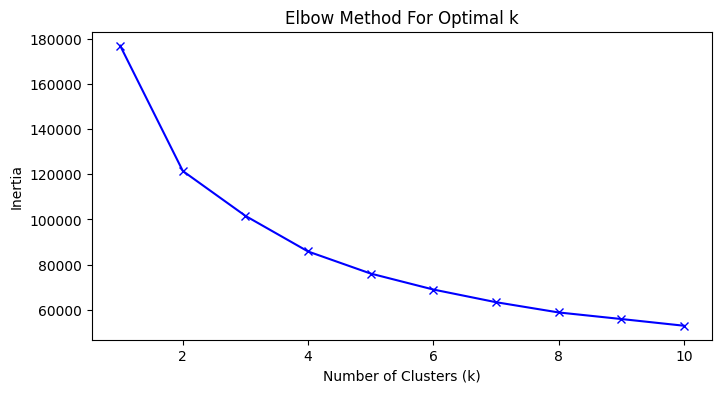

In [101]:
# ELBOW METHOD ---
inertia = []
K_range = range(1, 11)
for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

# Visualize the Elbow
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [102]:
# Generate Clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['risk_cluster'] = kmeans.fit_predict(X_scaled)

# Split Data for Classification
y_cluster = df['risk_cluster']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_scaled, y_cluster, test_size=0.2, random_state=42)

In [103]:
# Define Neural Network Architecture for Classification (4 classes)
# Structure: Input -> Dense -> BatchNorm -> ReLU -> Dropout -> Output (Softmax)
cluster_model = Sequential([
    Dense(128, input_dim=X_train_c.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.3),  # Prevents overfitting

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),

    # Output layer: 4 neurons for 4 clusters, softmax for probability distribution
    Dense(4, activation='softmax')
])

# Compile Model
cluster_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Early Stopping to prevent overfitting (stops training when validation loss stops improving)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train Model
history_c = cluster_model.fit(
    X_train_c, y_train_c,
    validation_data=(X_test_c, y_test_c),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


403/403 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8016 - loss: 0.5211 - val_accuracy: 0.9792 - val_loss: 0.0809
Epoch 2/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9297 - loss: 0.1788 - val_accuracy: 0.9742 - val_loss: 0.0691
Epoch 3/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9459 - loss: 0.1343 - val_accuracy: 0.9782 - val_loss: 0.0582
Epoch 4/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9443 - loss: 0.1345 - val_accuracy: 0.9804 - val_loss: 0.0571
Epoch 5/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9537 - loss: 0.1131 - val_accuracy: 0.9786 - val_loss: 0.0547
Epoch 6/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9550 - loss: 0.1108 - val_accuracy: 0.9817 - val_loss: 0.0551
Epoch 7/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9585 - loss: 0.1039 - val_accuracy: 0.9863 - val_loss: 0.0392
Epoch 8/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9635 - loss: 0.0909 - val_accuracy: 0.9845

In [108]:
# Show cluster distribution
print(df['risk_cluster'].value_counts())

risk_cluster
1    8210
0    5591
2    2288
Name: count, dtype: int64


In [109]:
# Predict probabilities
y_pred_probs = cluster_model.predict(X_test_c)
# Convert probabilities to class labels (0, 1, 2, 3)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Evaluate
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_classes):.2%}")
print("\nClassification Report:\n")
print(classification_report(y_test_c, y_pred_classes))

101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 99.41%

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1164
           1       1.00      0.99      0.99      1594
           2       0.99      0.99      0.99       460

    accuracy                           0.99      3218
   macro avg       0.99      0.99      0.99      3218
weighted avg       0.99      0.99      0.99      3218



In [110]:
def map_grade(score):
    if score > 85: return "A"
    elif score >= 70: return "B"
    elif score >= 55: return "C"
    elif score >= 50: return "D"
    else: return "F"

In [135]:
# Target is final_grade
y_grade = df['final_grade']
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(X_scaled, y_grade, test_size=0.2, random_state=42)

# Define Neural Network Architecture for Regression
# Structure: Input -> Dense -> BatchNorm -> ReLU -> Output (Linear)
nn_model = Sequential([
    Dense(512, input_dim=X_train_g.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

     Dense(64, activation='relu'),

 # Output layer: 1 neuron, linear activation for continuous value (0-100)
    Dense(1, activation='linear')
])

nn_model.compile(optimizer=Adam(learning_rate=0.01), loss=Huber(delta=1.0), metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

#Reduce LR when stuck
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

nn_model.fit(
    X_train_g, y_train_g,
    validation_data=(X_test_g, y_test_g),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


403/403 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 16.0788 - mae: 16.5687 - val_loss: 10.1105 - val_mae: 10.6028 - learning_rate: 0.0100
Epoch 2/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 10.1116 - mae: 10.5977 - val_loss: 8.9841 - val_mae: 9.4740 - learning_rate: 0.0100
Epoch 3/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 9.7367 - mae: 10.2235 - val_loss: 8.5591 - val_mae: 9.0334 - learning_rate: 0.0100
Epoch 4/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 9.4025 - mae: 9.8899 - val_loss: 8.7763 - val_mae: 9.2525 - learning_rate: 0.0100
Epoch 5/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 9.1957 - mae: 9.6811 - val_loss: 8.4847 - val_mae: 8.9618 - learning_rate: 0.0100
Epoch 6/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 9.1360 - mae: 9.6223 - val_loss: 8.5924 - val_mae: 9.0675 - learning_rate: 0.0100
Epoch 7/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 9.0688 - mae: 9.5512 - val_loss: 8.3364 - val_mae: 8.8044 - learning_rate: 0.0100
Epo

In [136]:
# Predict
grade_preds = grade_model.predict(X_test_g).flatten() # Flatten 2D array to 1D

# 1. Calculate R-Squared
r2 = r2_score(y_test_g, grade_preds)

# 2. Calculate Accuracy (1 - MAPE)
mask = y_test_g != 0  # Filtering out 0 grades to avoid division error
mape = np.mean(np.abs((y_test_g[mask] - grade_preds[mask]) / y_test_g[mask]))
accuracy = 1 - mape

# 3. Print
print(f"Model Statistical Fit (R²): {r2:.2%}")
print(f"Prediction Accuracy:        {accuracy:.2%}")
print(f"Example: Real Grade: {y_test_g.iloc[10]}, Predicted: {grade_preds[10]:.1f}")

101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model Statistical Fit (R²): 53.93%
Prediction Accuracy:        80.93%
Example: Real Grade: 65, Predicted: 65.1


In [138]:
import joblib
import tensorflow as tf
from google.colab import files
import zipfile
import os
import pandas as pd
import numpy as np

# ==========================================
# 1. SAVE THE TRAINED MODELS
# ==========================================
print("Saving models to disk...")

# 1. Save Scaler (The translator for data)
joblib.dump(scaler, 'academIQ_scaler.pkl')

# 2. Save the Grade Prediction Model (Your 'nn_model')
nn_model.save('academIQ_grade_model.keras')

# 3. Save the Risk Classification Model (Your 'cluster_model')
cluster_model.save('academIQ_risk_model.keras')

# ==========================================
# 2. GENERATE THE INFERENCE SCRIPT
# ==========================================
inference_code = """
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
import os

# Define paths (assumes models are in the same folder as this script)
BASE_DIR = os.path.dirname(os.path.abspath(__file__))
SCALER_PATH = os.path.join(BASE_DIR, 'academIQ_scaler.pkl')
RISK_MODEL_PATH = os.path.join(BASE_DIR, 'academIQ_risk_model.keras')
GRADE_MODEL_PATH = os.path.join(BASE_DIR, 'academIQ_grade_model.keras')

class StudentPredictor:
    def __init__(self):
        # Load artifacts
        try:
            self.scaler = joblib.load(SCALER_PATH)
            self.risk_model = tf.keras.models.load_model(RISK_MODEL_PATH)
            self.grade_model = tf.keras.models.load_model(GRADE_MODEL_PATH)
            print("✅ AcademIQ Models loaded successfully.")
        except Exception as e:
            print(f"❌ Error loading models: {e}")
            raise e

    def preprocess(self, data_dict):
        '''
        Transforms raw dictionary data into the scaled format the models expect.
        '''
        # Convert dictionary to DataFrame
        df = pd.DataFrame([data_dict])

        # 1. Feature Engineering (Must match training logic exactly)
        # Avoid division by zero with +1
        df['avg_daily_time'] = df['total_time_spent'] / (df['active_days'] + 1)
        df['clicks_per_day'] = df['all_clicks'] / (df['active_days'] + 1)

        # 2. Log Transformation for skewed features
        skewed_cols = ['all_clicks', 'material_clicks', 'total_time_spent', 'avg_daily_time', 'clicks_per_day']
        for col in skewed_cols:
            if col in df.columns:
                df[col] = np.log1p(df[col])

        # 3. Select & Order Columns (Critical for Scaler)
        # These must match the columns used during X_scaled creation
        expected_cols = [
            'all_clicks', 'active_days', 'access_frequency', 'material_clicks',
            'avg_quiz_score', 'quiz_attempts', 'avg_assignment_score',
            'assignment_submissions', 'total_time_spent', 'avg_daily_time', 'clicks_per_day'
        ]

        # Ensure columns exist and are in order (fill missing with 0)
        for col in expected_cols:
            if col not in df.columns:
                df[col] = 0

        X_raw = df[expected_cols]

        # 4. Scale
        X_scaled = self.scaler.transform(X_raw)
        return X_scaled

    def predict(self, student_data):
        '''
        Main function to call from Backend API.
        Input: dict containing 'all_clicks', 'active_days', etc.
        Output: dict with 'risk_cluster' (int) and 'predicted_grade' (float)
        '''
        # Preprocess
        X_processed = self.preprocess(student_data)

        # Inference
        # 1. Predict Risk (Returns cluster ID)
        risk_probs = self.risk_model.predict(X_processed, verbose=0)
        risk_cluster = int(np.argmax(risk_probs, axis=1)[0])

        # 2. Predict Grade (Returns 0-100 score)
        predicted_grade = float(self.grade_model.predict(X_processed, verbose=0)[0][0])

        # Clip grade to realistic bounds (0 to 100)
        predicted_grade = max(0.0, min(100.0, predicted_grade))

        return {
            'risk_cluster': risk_cluster,
            'predicted_grade': round(predicted_grade, 2)
        }

if __name__ == "__main__":
    # Test block for backend developer
    predictor = StudentPredictor()

    # Sample Test Data
    test_student = {
        'all_clicks': 500,
        'active_days': 20,
        'access_frequency': 5,
        'material_clicks': 50,
        'avg_quiz_score': 85,
        'quiz_attempts': 10,
        'avg_assignment_score': 90,
        'assignment_submissions': 5,
        'total_time_spent': 1200
    }

    print(f"Testing with student data: {test_student}")
    result = predictor.predict(test_student)
    print("Inference Result:", result)
"""

with open("inference.py", "w") as f:
    f.write(inference_code)

print("✅ inference.py generated.")

# ==========================================
# 3. ZIP AND DOWNLOAD
# ==========================================
zip_filename = 'academIQ_backend_package.zip'
files_to_zip = [
    'academIQ_scaler.pkl',
    'academIQ_risk_model.keras',
    'academIQ_grade_model.keras',
    'inference.py'
]

print(f"Zipping files into {zip_filename}...")
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)
            print(f"  - Added {file}")
        else:
            print(f"  ⚠️ Warning: {file} missing, skipping.")

files.download(zip_filename)
print("🚀 Download started! Send this ZIP file to your backend colleague.")

Saving models to disk...
✅ inference.py generated.
Zipping files into academIQ_backend_package.zip...
  - Added academIQ_scaler.pkl
  - Added academIQ_risk_model.keras
  - Added academIQ_grade_model.keras
  - Added inference.py


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🚀 Download started! Send this ZIP file to your backend colleague.
